In [3]:
import pandas as pd
import numpy as np

# abrimos el archivo y lo guardamos en un objeto que llamaremos "data"

with open("/content/drive/MyDrive/ML/rna1.csv","r") as file:
  data = pd.read_csv(file)
data.head()

,Class,RTN2,NDRG2,CCDC113,FAM63A,ACADS,GMDS,HLA.H,SEMA4A,ETS2,...,ELP2,ALOX5,AMN1,CERCAM,SEMA3C,KRT8,TP53INP2,JAM3,ZNF680,PBX1
0,tipus1,4.362183,7.533461,3.956124,4.457170,2.256817,6.017940,5.006907,3.217812,4.734446,...,6.581283,2.657454,4.015401,5.155279,7.709125,11.196906,5.564430,3.991982,3.352637,7.880923
1,tipus1,1.984492,7.455194,5.427623,5.440957,4.028813,4.341692,6.178668,2.864659,5.411029,...,7.150755,2.979337,2.948135,6.071058,6.657197,9.584007,5.923025,3.343699,3.637142,7.807082
2,tipus1,1.727323,8.079968,2.227300,5.543480,2.629855,6.363030,6.039563,5.946028,5.651670,...,6.430628,3.373541,3.063473,5.737308,3.978155,10.423796,5.980527,3.289314,3.633879,7.441712
3,tipus1,4.363996,5.793750,3.544866,4.737114,4.269101,4.001104,7.087633,5.007565,5.902449,...,5.606317,5.027281,2.883810,6.440455,6.891619,10.056940,4.939562,4.369947,3.987233,8.021253
4,tipus1,2.447562,7.158993,4.691256,4.808728,2.442135,7.029723,5.936138,5.901459,6.641225,...,5.903435,3.443978,3.883034,4.812939,3.298393,8.969229,6.410238,3.371594,3.264969,8.138553


In [15]:
data['labels'] = pd.Categorical(data.Class).codes

In [16]:
from sklearn.model_selection import train_test_split
np.random.seed(12345)
data_numeric = data.drop(["Class", "labels"], axis = 1)
data_labels = data["labels"]
data_train, data_test, labels_train, labels_test = train_test_split(data_numeric, data_labels, test_size=0.33, stratify = data_labels)

In [17]:
# importamos las bibliotecas necesarias

import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from keras.optimizers import SGD


Primer modelo con una capa oculta de 30 nodos:

In [18]:
np.random.seed(12345)
modelo1 = Sequential()
modelo1.add(Dense(200,activation = "relu", input_shape=(200,)))
modelo1.add(Dense(30,activation="relu"))
modelo1.add(Dense(3, activation="softmax"))

In [19]:
# añadimos el optimizador y la loss function, en este caso será
# 'sparse_categorical_crossentropy' ya que selas distintas clases
# son categóricas codificadas como 0,1,2, etc.

modelo1.compile(optimizer = SGD(learning_rate=0.01),
                loss='sparse_categorical_crossentropy',
                metrics=['acc'])

In [20]:
modelo1.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 200)               40200     
                                                                 
 dense_4 (Dense)             (None, 30)                6030      
                                                                 
 dense_5 (Dense)             (None, 3)                 93        
                                                                 
Total params: 46323 (180.95 KB)
Trainable params: 46323 (180.95 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [35]:
np.random.seed(12345)
modelo1_hist = modelo1.fit(data_train, labels_train,
                           epochs = 100,
                           validation_data=(data_test,labels_test))

Epoch 1/100
4/4 [==============================] - 0s 36ms/step - loss: 0.0169 - acc: 1.0000 - val_loss: 0.2877 - val_acc: 0.9000
Epoch 2/100
4/4 [==============================] - 0s 19ms/step - loss: 0.0156 - acc: 1.0000 - val_loss: 0.2182 - val_acc: 0.9000
Epoch 3/100
4/4 [==============================] - 0s 19ms/step - loss: 0.0406 - acc: 0.9900 - val_loss: 0.4515 - val_acc: 0.8800
Epoch 4/100
4/4 [==============================] - 0s 19ms/step - loss: 0.0229 - acc: 0.9900 - val_loss: 0.2474 - val_acc: 0.9200
Epoch 5/100
4/4 [==============================] - 0s 18ms/step - loss: 0.0146 - acc: 1.0000 - val_loss: 0.2523 - val_acc: 0.9200
Epoch 6/100
4/4 [==============================] - 0s 18ms/step - loss: 0.0148 - acc: 1.0000 - val_loss: 0.2692 - val_acc: 0.9200
Epoch 7/100
4/4 [==============================] - 0s 13ms/step - loss: 0.0150 - acc: 1.0000 - val_loss: 0.3400 - val_acc: 0.8800
Epoch 8/100
4/4 [==============================] - 0s 19ms/step - loss: 0.0163 - acc: 1.00

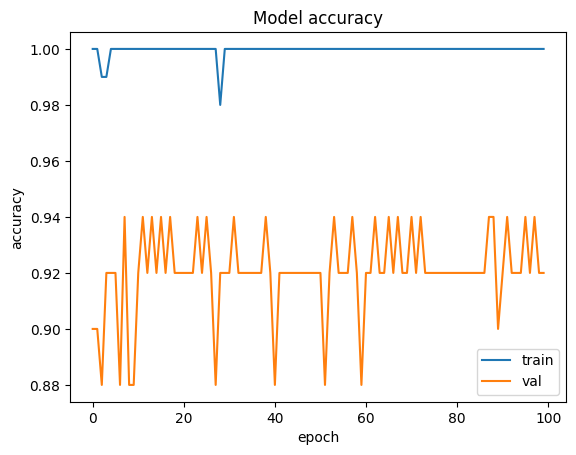

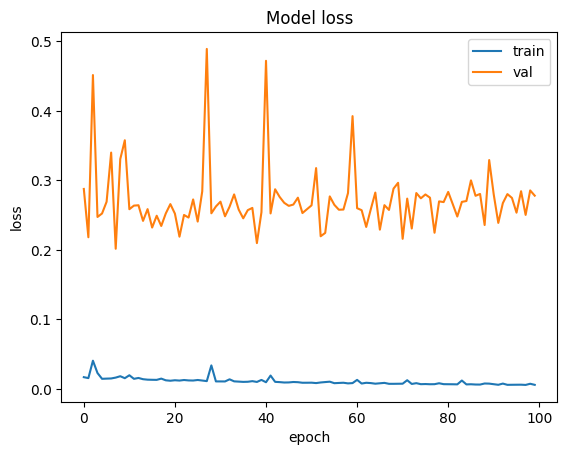

In [36]:
import matplotlib.pyplot as plt


# visualizar accuracy

plt.plot(modelo1_hist.history['acc'])
plt.plot(modelo1_hist.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='lower right')
plt.show()

# visualizar loss
plt.plot(modelo1_hist.history['loss'])
plt.plot(modelo1_hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

2/2 [==============================] - 0s 6ms/step


Text(113.9222222222222, 0.5, 'Predicted')

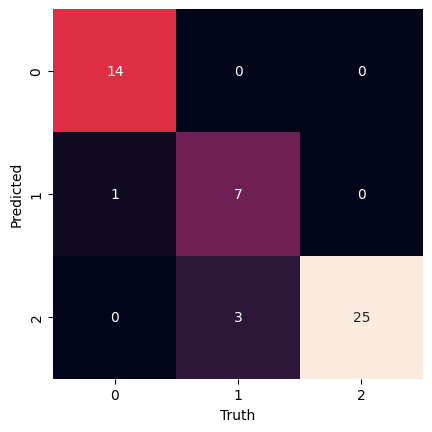

In [37]:
# representamos la matriz de confusión
import seaborn as sns
from sklearn.metrics import confusion_matrix
preds = np.argmax(modelo1.predict(data_test), axis = 1)
mat = confusion_matrix(preds, labels_test)
names = np.unique(labels_test)
sns.heatmap(mat, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=names, yticklabels=names)
plt.xlabel('Truth')
plt.ylabel('Predicted')

In [33]:
from sklearn.metrics import classification_report
print(classification_report(labels_test, preds))

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.88      0.70      0.78        10
           2       0.89      1.00      0.94        25

    accuracy                           0.92        50
   macro avg       0.92      0.88      0.90        50
weighted avg       0.92      0.92      0.92        50



Segundo modelo con dos capas ocultas, de 50 y 30 nodos:

In [27]:
np.random.seed(12345)
modelo2 = Sequential()
modelo2.add(Dense(200,activation = "relu", input_shape=(200,)))
modelo2.add(Dense(50,activation="relu"))
modelo2.add(Dense(30, activation = "relu"))
modelo2.add(Dense(3, activation="softmax"))

In [28]:
modelo2.compile(optimizer = SGD(learning_rate=0.01),
                loss='sparse_categorical_crossentropy',
                metrics=['acc'])

In [29]:
modelo2.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 200)               40200     
                                                                 
 dense_7 (Dense)             (None, 50)                10050     
                                                                 
 dense_8 (Dense)             (None, 30)                1530      
                                                                 
 dense_9 (Dense)             (None, 3)                 93        
                                                                 
Total params: 51873 (202.63 KB)
Trainable params: 51873 (202.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [39]:
np.random.seed(12345)
modelo2_hist = modelo2.fit(data_train, labels_train,
                           epochs = 100,
                           validation_data=(data_test,labels_test))

Epoch 1/100
4/4 [==============================] - 0s 47ms/step - loss: 0.0351 - acc: 1.0000 - val_loss: 0.1879 - val_acc: 0.9400
Epoch 2/100
4/4 [==============================] - 0s 13ms/step - loss: 0.0415 - acc: 1.0000 - val_loss: 0.1893 - val_acc: 0.9400
Epoch 3/100
4/4 [==============================] - 0s 18ms/step - loss: 0.0488 - acc: 0.9900 - val_loss: 0.1903 - val_acc: 0.9200
Epoch 4/100
4/4 [==============================] - 0s 18ms/step - loss: 0.0454 - acc: 0.9900 - val_loss: 0.2170 - val_acc: 0.9400
Epoch 5/100
4/4 [==============================] - 0s 14ms/step - loss: 0.0268 - acc: 1.0000 - val_loss: 0.2664 - val_acc: 0.9200
Epoch 6/100
4/4 [==============================] - 0s 19ms/step - loss: 0.0318 - acc: 1.0000 - val_loss: 0.2343 - val_acc: 0.9400
Epoch 7/100
4/4 [==============================] - 0s 19ms/step - loss: 0.0238 - acc: 1.0000 - val_loss: 0.1944 - val_acc: 0.9400
Epoch 8/100
4/4 [==============================] - 0s 13ms/step - loss: 0.0240 - acc: 1.00

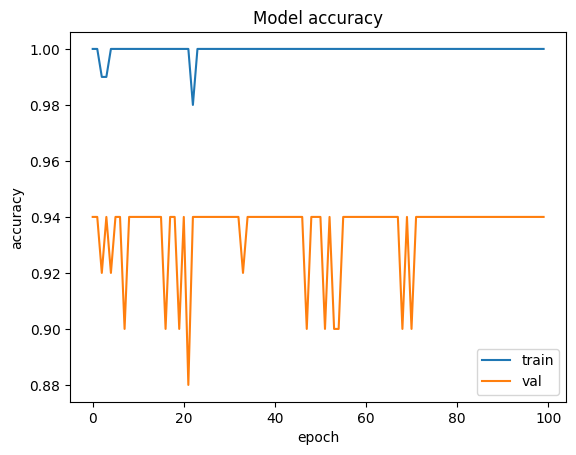

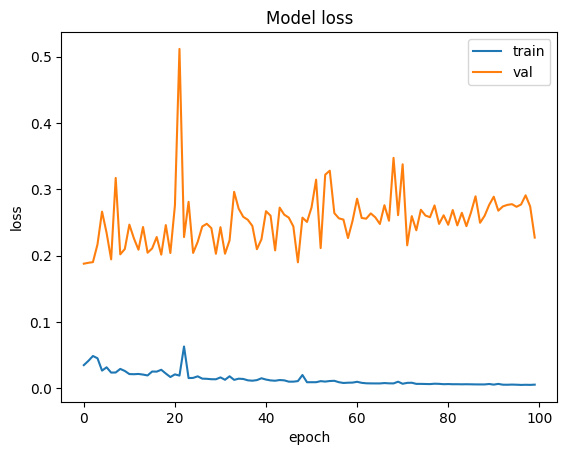

In [41]:

# visualizar accuracy

plt.plot(modelo2_hist.history['acc'])
plt.plot(modelo2_hist.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='lower right')
plt.show()

# visualizar loss
plt.plot(modelo2_hist.history['loss'])
plt.plot(modelo2_hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

2/2 [==============================] - 0s 6ms/step


Text(113.9222222222222, 0.5, 'Predicted')

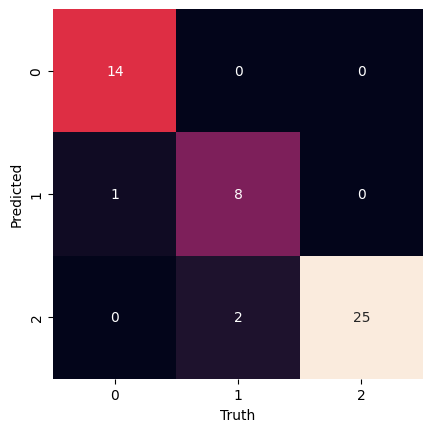

In [42]:
preds = np.argmax(modelo2.predict(data_test), axis = 1)
mat = confusion_matrix(preds, labels_test)
names = np.unique(labels_test)
sns.heatmap(mat, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=names, yticklabels=names)
plt.xlabel('Truth')
plt.ylabel('Predicted')

In [43]:
print(classification_report(labels_test, preds))

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.89      0.80      0.84        10
           2       0.93      1.00      0.96        25

    accuracy                           0.94        50
   macro avg       0.94      0.91      0.92        50
weighted avg       0.94      0.94      0.94        50

